# Consensus Protocol Scoring — Family Radar Profiles

Computes per-algorithm scores on six assessment axes, aggregates them by
consensus family, and renders radar charts.

**Axes**:

1. `S_net` — Network scalability (log-scaled Min-Max, $N_{min}=1$, $N_{max}=50{,}000$)
2. `S_tps` — Transaction throughput (log-scaled Min-Max, $V_{min}=1$, $V_{max}=200{,}000$)
3. `S_dec` — Decentralisation composite ($w_{access}=0.3$, $w_{selection}=0.4$, $w_{participation}=0.3$)
4. `S_sec` — Security baseline (taxonomic penalties not applied)
5. `S_bif` — Bifurcation resistance (Deterministic = 9, Hybrid = 6, Probabilistic = 3)
6. `S_res` — Resource efficiency (VH = 1, H = 3, M = 6, L = 9)

All axes are bounded on $S \in [0,\,9]$.


## 1. Setup and visual configuration

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

pd.set_option("display.float_format", lambda x: f"{x:.2f}")
pd.set_option("display.max_rows", 40)
pd.set_option("display.max_columns", 20)

# Visual Configuration
CONFIG = {
    # Dark Colours
        "family_colors": {
        "C":  "#60368A",   # Competition-based
        "S":  "#A1192C",   # Selection-based
        "BA": "#CC7001",   # Byzantine Agreement-based
        "NL": "#5B6645",   # Non-Linear Data-based
    },

    # Polygon styling
    "fill_alpha":      0.45,    
    "line_width":      1.6,     
    "line_alpha":      1.0,

    # Radar grid
    "grid_color":      "#9a9a9a",
    "grid_width":      0.6,
    "grid_linestyle":  "-",
    "spine_color":     "#666666",
    "n_grid_levels":   5,

    # Typography
    "font_family":      "DejaVu Serif",
    "title_fontsize":   13,
    "title_fontweight": "normal",
    "title_color":      "#000000",
    "axis_label_fontsize": 10,
    "axis_label_color":    "#000000",
    "tick_fontsize":    8,
    "tick_color":       "#666666",

    # Value annotations next to each vertex
    "show_value_labels":   False,
    "value_label_fontsize": 9,
    "value_label_offset":   0.55,

    # Figure
    "fig_size":   (11, 10),
    "fig_dpi":    130,
    "background": "#ffffff",
    "subplot_wspace": 0.40,
    "subplot_hspace": 0.45,

    # Aggregation displayed in the chart
    # one of: "median", "mean"
    "aggregation": "mean",

    # Optional super-title above the grid (None to hide)
    "suptitle": None,
}

# Apply font family globally for this notebook
plt.rcParams["font.family"] = CONFIG["font_family"]


## 2. Methodology constants

In [2]:
# Throughput bounds (TPS)
V_MIN, V_MAX = 1, 200_000

# Network size bounds (also used as upper bound for D_participation)
N_MIN, N_MAX = 1, 50_000
N_MIN_PARTICIPATION = 4

# Fault-tolerance class optima
F_MAX_HONEST = 0.50 
F_MAX_BFT    = 0.33

# Family security penalties
FAMILY_PENALTY = {"BA": 1, "C": 2, "S": 3, "NL": 3}

# Resource consumption -> efficiency score (inverse of consumption)
RES_MAP = {"VH": 0, "H": 3, "M": 6, "L": 9}

# Bifurcation resistance class -> score
BIF_MAP = {"Deterministic": 9, "Hybrid": 6, "Probabilistic": 3}

# Access model -> D_access
ACCESS_MAP = {"Public": 9.0, "Federated": 4.5, "Private": 1.0}

# Selection mechanism -> D_selection
#   open      : open competition / uniform lottery
#   stake     : stake-weighted, no delegation
#   delegated : limited size validator set
#   committee : authority/reputation/fixed committee
#   single    : single coordinator
SELECTION_MAP = {"open": 9, "stake": 7, "delegated": 4, "committee": 2, "single": 1}

# Composite weights for S_dec
W_ACCESS, W_SELECTION, W_PARTICIPATION = 0.3, 0.4, 0.3

# Score scale
S_MAX = 9


## 3. Per-axis scoring functions

In [3]:
def s_tps(tps):
    if tps is None or (isinstance(tps, float) and math.isnan(tps)) or tps <= 0:
        return np.nan
    num = math.log10(tps) - math.log10(V_MIN)
    den = math.log10(V_MAX) - math.log10(V_MIN)
    return S_MAX * num / den


def s_net(n):
    if n is None or (isinstance(n, float) and math.isnan(n)) or n <= 0:
        return np.nan
    n_clamped = min(max(n, N_MIN), N_MAX)
    num = math.log10(n_clamped) - math.log10(N_MIN)
    den = math.log10(N_MAX) - math.log10(N_MIN)
    return S_MAX * num / den

def s_sec_noPenalty(F, model):
    if F is None or (isinstance(F, float) and math.isnan(F)):
        return np.nan
    f_max = F_MAX_HONEST if model == "honest" else F_MAX_BFT
    return min(S_MAX, S_MAX * F / f_max)

def s_sec(F, model, family):
    if F is None or (isinstance(F, float) and math.isnan(F)):
        return np.nan
    f_max = F_MAX_HONEST if model == "honest" else F_MAX_BFT
    base = min(S_MAX, S_MAX * F / f_max)
    return max(0, base - FAMILY_PENALTY.get(family, 0))


def s_res(category):
    return RES_MAP.get(category, np.nan)


def s_bif(category):
    return BIF_MAP.get(category, np.nan)


def d_participation(n):
    if n is None or (isinstance(n, float) and math.isnan(n)) or n <= 0:
        return np.nan
    n_clamped = min(max(n, N_MIN_PARTICIPATION), N_MAX)
    num = math.log10(n_clamped) - math.log10(N_MIN_PARTICIPATION)
    den = math.log10(N_MAX) - math.log10(N_MIN_PARTICIPATION)
    return S_MAX * num / den


def s_dec(access, selection, n):
    d_a = ACCESS_MAP.get(access, np.nan)
    d_s = SELECTION_MAP.get(selection, np.nan)
    d_p = d_participation(n)
    if any(isinstance(x, float) and math.isnan(x) for x in (d_a, d_s, d_p)):
        return np.nan
    return W_ACCESS * d_a + W_SELECTION * d_s + W_PARTICIPATION * d_p


## 4. Algorithm dataset


In [4]:
GLOBAL = N_MAX 

algorithms = [
    # ---- Byzantine Agreement (BA) -------------------------------------------------
    ("BFT-SMaRt",        "BA",  10000,       2,     10,    "Private", "M", 0.33, "bft",    "committee", "Deterministic"),
    ("dBFT",             "BA",   1000,   15000,      7,    "Public",  "M", 0.33, "bft",    "committee", "Deterministic"),
    ("FBA (Ripple)",     "BA",   1500,    5000,     35,    "Public",  "M", 0.20, "bft",    "committee", "Deterministic"),
    ("FBA (Stellar)",    "BA",    800,    5000,     64,    "Public",  "H", 0.20, "bft",    "committee", "Deterministic"),
    ("HoneyBadgerBFT",   "BA",  20000,   30000,     40,    "Private", "M", 0.33, "bft",    "committee", "Deterministic"),
    ("IBFT",             "BA",    400,    1500,      4,    "Private", "M", 0.33, "bft",    "committee", "Deterministic"),
    ("pBFT",             "BA",    650,      13,      4,    "Private", "M", 0.33, "bft",    "committee", "Deterministic"),
    ("PoReputation",     "BA",   1300,    5000,     50,    "Private", "L", 0.50, "bft", "committee", "Deterministic"),
    ("PoValidation",     "BA",    438,    3450,    128,    "Public",  "M", 0.33, "bft",    "committee", "Deterministic"),
    ("sBFT",             "BA",    172,     650,    209,    "Private", "L", 0.33, "bft",    "committee", "Deterministic"),
    ("vBFT",             "BA",   5000,    1000,     15,    "Public",  "M", 0.33, "bft",    "committee", "Deterministic"),
    ("YAC",              "BA",     40,    4000,     50,    "Private", "L", 0.33, "bft",    "committee", "Deterministic"),

    # ---- Competition (C) ----------------------------------------------------------
    ("PoW (Bitcoin)",    "C",       7,  600000, GLOBAL, "Public",  "VH", 0.50, "honest", "open",     "Probabilistic"),
    ("PoSpace (Chia)",   "C",   19.25,   51950, GLOBAL, "Public",  "M",  0.50, "honest", "open",     "Probabilistic"),

    # ---- Non-Linear (NL) ----------------------------------------------------------
    ("Tangle 1.0",       "NL",  112.7,   30000, GLOBAL, "Public",  "L",  0.10, "honest", "single",   "Probabilistic"),
    ("Tangle 2.0",       "NL",   1000,   10000,  10000,  "Public",  "L",  0.33, "bft",    "open",     "Hybrid"),
    ("Hashgraph",        "NL",  20000,    3500,     32,    "Public",  "L",  0.33, "bft",    "committee","Deterministic"),
    ("Avalanche",        "NL",   5000,    1000,   2000,   "Public",  "M",  0.50, "honest", "stake",    "Probabilistic"),

    # ---- Selection (S) ------------------------------------------------------------
    ("PoS (Ethereum)",   "S",    13.3,   12000, GLOBAL, "Public",  "L",  0.33, "honest",    "stake",    "Hybrid"),
    ("AuRa",             "S",     398,    5000,      4,    "Private", "L",  0.50, "honest", "committee","Deterministic"),
    ("dPoS (Bitshares)", "S",     450,    2500,    128,    "Public",  "L",  0.50, "honest", "delegated","Probabilistic"),
    ("Leased PoS",       "S",      71,   60000, GLOBAL, "Public",  "L",  0.50, "honest", "stake",    "Probabilistic"),
    ("Liquid PoS",       "S",     300,    8000, GLOBAL, "Public",  "L",  0.33, "honest",    "delegated","Hybrid"),
    ("PoS Velocity",     "S",      70,   60000, GLOBAL, "Public",  "L",  0.50, "honest", "stake",    "Probabilistic"),
    ("Pure PoS",         "S",    6000,    2820, GLOBAL, "Public",  "L",  0.33, "honest",    "open",     "Deterministic"),
    ("PoActivity",       "S",      14, 1800000, GLOBAL, "Public",  "M",  0.50, "honest", "stake",    "Probabilistic"),
    ("PoAuthority",      "S",     165,   10000,    101,    "Public",  "L",  0.50, "honest", "committee","Deterministic"),
    ("PoBelievability",  "S",  GLOBAL,   30000, GLOBAL, "Public",  "L",  0.33, "honest",    "stake",    "Deterministic"),
    ("PoET",             "S",      35,    None,      8,    "Private", "L",  0.50, "honest", "delegated","Probabilistic"),
    ("PoImportance",     "S",       2,   60000, GLOBAL, "Public",  "L",  0.50, "honest", "stake",    "Probabilistic"),
    ("Raft (CFT)",       "S",    1530,    2000,      3,    "Private", "L",  0.50, "honest", "committee","Deterministic"),
]

cols = ["algorithm","family","tps","latency","n","access","res","fault_tol","model","selection","bif"]
df = pd.DataFrame(algorithms, columns=cols)
print(f"Loaded {len(df)} algorithms across {df['family'].nunique()} families")
df.head()


Loaded 31 algorithms across 4 families


,algorithm,family,tps,latency,n,access,res,fault_tol,model,selection,bif
0,BFT-SMaRt,BA,10000.00,2.00,10,Private,M,0.33,bft,committee,Deterministic
1,dBFT,BA,1000.00,15000.00,7,Public,M,0.33,bft,committee,Deterministic
2,FBA (Ripple),BA,1500.00,5000.00,35,Public,M,0.20,bft,committee,Deterministic
3,FBA (Stellar),BA,800.00,5000.00,64,Public,H,0.20,bft,committee,Deterministic
4,HoneyBadgerBFT,BA,20000.00,30000.00,40,Private,M,0.33,bft,committee,Deterministic


## 5. Compute per-algorithm scores

In [5]:
df["S_net"] = df["n"].apply(s_net)
df["S_tps"] = df["tps"].apply(s_tps)
df["S_dec"] = df.apply(lambda r: s_dec(r["access"], r["selection"], r["n"]), axis=1)
# df["S_sec"] = df.apply(lambda r: s_sec(r["fault_tol"], r["model"]), axis=1) #No Family Penalty
df["S_sec"] = df.apply(lambda r: s_sec(r["fault_tol"], r["model"], r["family"]), axis=1)
df["S_bif"] = df["bif"].apply(s_bif)
df["S_res"] = df["res"].apply(s_res)

score_cols = ["S_net", "S_tps", "S_dec", "S_sec", "S_bif", "S_res"]
df[["algorithm", "family", *score_cols]].round(2)


,algorithm,family,S_net,S_tps,S_dec,S_sec,S_bif,S_res
0,BFT-SMaRt,BA,1.92,6.79,1.36,8.00,9,6
1,dBFT,BA,1.62,5.09,3.66,8.00,9,6
2,FBA (Ripple),BA,2.96,5.39,4.12,4.45,9,6
3,FBA (Stellar),BA,3.46,4.93,4.29,4.45,9,3
4,HoneyBadgerBFT,BA,3.07,7.30,1.76,8.00,9,6
5,IBFT,BA,1.15,4.42,1.10,8.00,9,6
6,pBFT,BA,1.15,4.78,1.10,8.00,9,6
7,PoReputation,BA,3.25,5.29,1.82,8.00,9,9
8,PoValidation,BA,4.04,4.48,4.49,8.00,9,6
9,sBFT,BA,4.44,3.80,2.23,8.00,9,9


## 6. Aggregate by consensus family

In [6]:
family_median = df.groupby("family")[score_cols].median().round(2)
family_mean   = df.groupby("family")[score_cols].mean().round(2)

print("Median by family")
print(family_median)
print("\nMean by family")
print(family_mean)


Median by family
        S_net  S_tps  S_dec  S_sec  S_bif  S_res
family                                          
BA       3.01   5.01   2.03   8.00   9.00   6.00
C        9.00   1.81   9.00   7.00   3.00   3.00
NL       6.99   5.69   6.54   6.00   4.50   9.00
S        9.00   3.76   8.20   6.00   6.00   9.00

Mean by family
        S_net  S_tps  S_dec  S_sec  S_bif  S_res
family                                          
BA       2.71   5.11   2.64   7.41   9.00   6.50
C        9.00   1.81   9.00   7.00   3.00   3.00
NL       6.47   5.54   6.43   4.50   5.25   8.25
S        6.44   3.84   6.09   5.06   5.77   8.77


## 7. Radar chart — family performance profiles


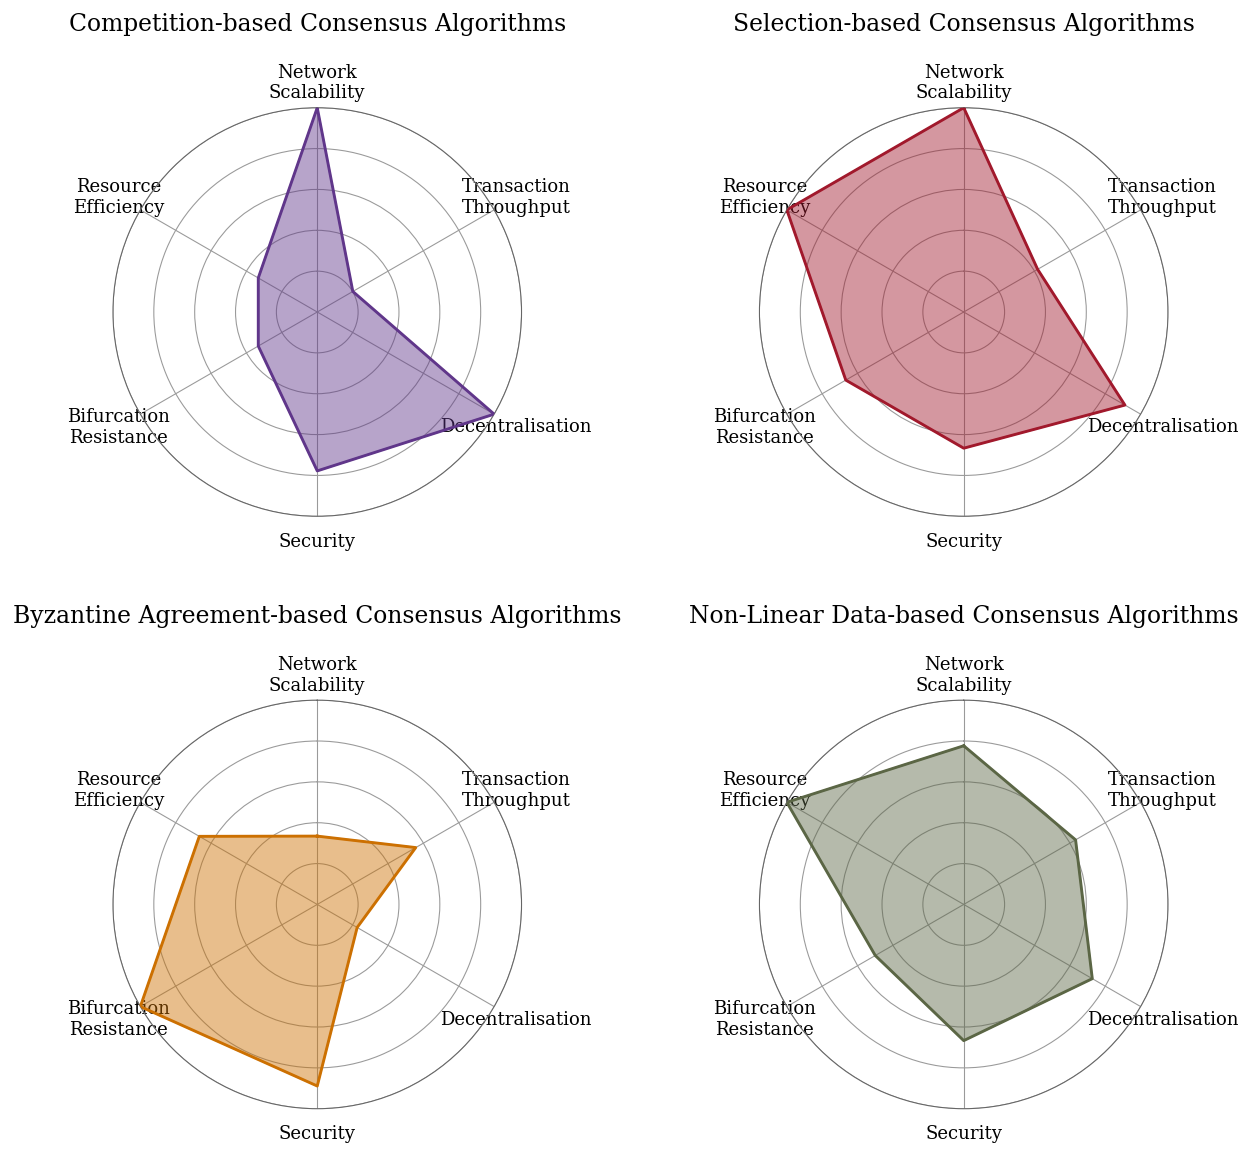

In [7]:
# AGGREGATION: MEDIAN
# Axis order
AXIS_SPEC = [
    ("S_net", "Network\nScalability"),
    ("S_tps", "Transaction\nThroughput"),
    ("S_dec", "Decentralisation"),
    ("S_sec", "Security"),
    ("S_bif", "Bifurcation\nResistance"),
    ("S_res", "Resource\nEfficiency"),
]
plot_cols   = [c for c, _ in AXIS_SPEC]
axis_labels = [lab for _, lab in AXIS_SPEC]

#Radar chart order 
display_order = ["C", "S", "BA", "NL"]
family_titles = {
    "C":  "Competition-based Consensus Algorithms",
    "S":  "Selection-based Consensus Algorithms",
    "BA": "Byzantine Agreement-based Consensus Algorithms",
    "NL": "Non-Linear Data-based Consensus Algorithms",
}

# Choose aggregation
agg_table = family_median


def draw_radar(ax, values, color, title):
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

    vals_closed   = values + values[:1]
    angles_closed = angles + angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.fill(angles_closed, vals_closed,
            color=color, alpha=CONFIG["fill_alpha"], zorder=2)
    ax.plot(angles_closed, vals_closed,
            color=color, linewidth=CONFIG["line_width"],
            alpha=CONFIG["line_alpha"], zorder=3)

    ax.set_xticks(angles)
    ax.set_xticklabels(axis_labels,
                       fontsize=CONFIG["axis_label_fontsize"],
                       color=CONFIG["axis_label_color"])

    levels = np.linspace(0, S_MAX, CONFIG["n_grid_levels"] + 1)[1:]
    ax.set_yticks(levels)
    ax.set_yticklabels([])
    ax.set_ylim(0, S_MAX)

    ax.grid(color=CONFIG["grid_color"],
            linewidth=CONFIG["grid_width"],
            linestyle=CONFIG["grid_linestyle"],
            zorder=1)
    ax.spines["polar"].set_color(CONFIG["spine_color"])
    ax.spines["polar"].set_linewidth(CONFIG["grid_width"])

    ax.set_title(title,
                 fontsize=CONFIG["title_fontsize"],
                 fontweight=CONFIG["title_fontweight"],
                 color=CONFIG["title_color"],
                 pad=18)
    if CONFIG["show_value_labels"]:
        for ang, val in zip(angles, values):
            ax.text(ang, val + CONFIG["value_label_offset"], f"{val:.1f}",
                    ha="center", va="center",
                    fontsize=CONFIG["value_label_fontsize"],
                    color=color, fontweight="bold")

fig, axs = plt.subplots(2, 2,
                        figsize=CONFIG["fig_size"],
                        dpi=CONFIG["fig_dpi"],
                        subplot_kw=dict(polar=True),
                        facecolor=CONFIG["background"])

if CONFIG["suptitle"]:
    fig.suptitle(CONFIG["suptitle"], fontsize=15, y=0.995)

for ax, fam in zip(axs.flat, display_order):
    values = agg_table.loc[fam, plot_cols].tolist()
    draw_radar(ax, values,
               color=CONFIG["family_colors"][fam],
               title=family_titles[fam])

plt.subplots_adjust(wspace=CONFIG["subplot_wspace"],
                    hspace=CONFIG["subplot_hspace"])
plt.show()


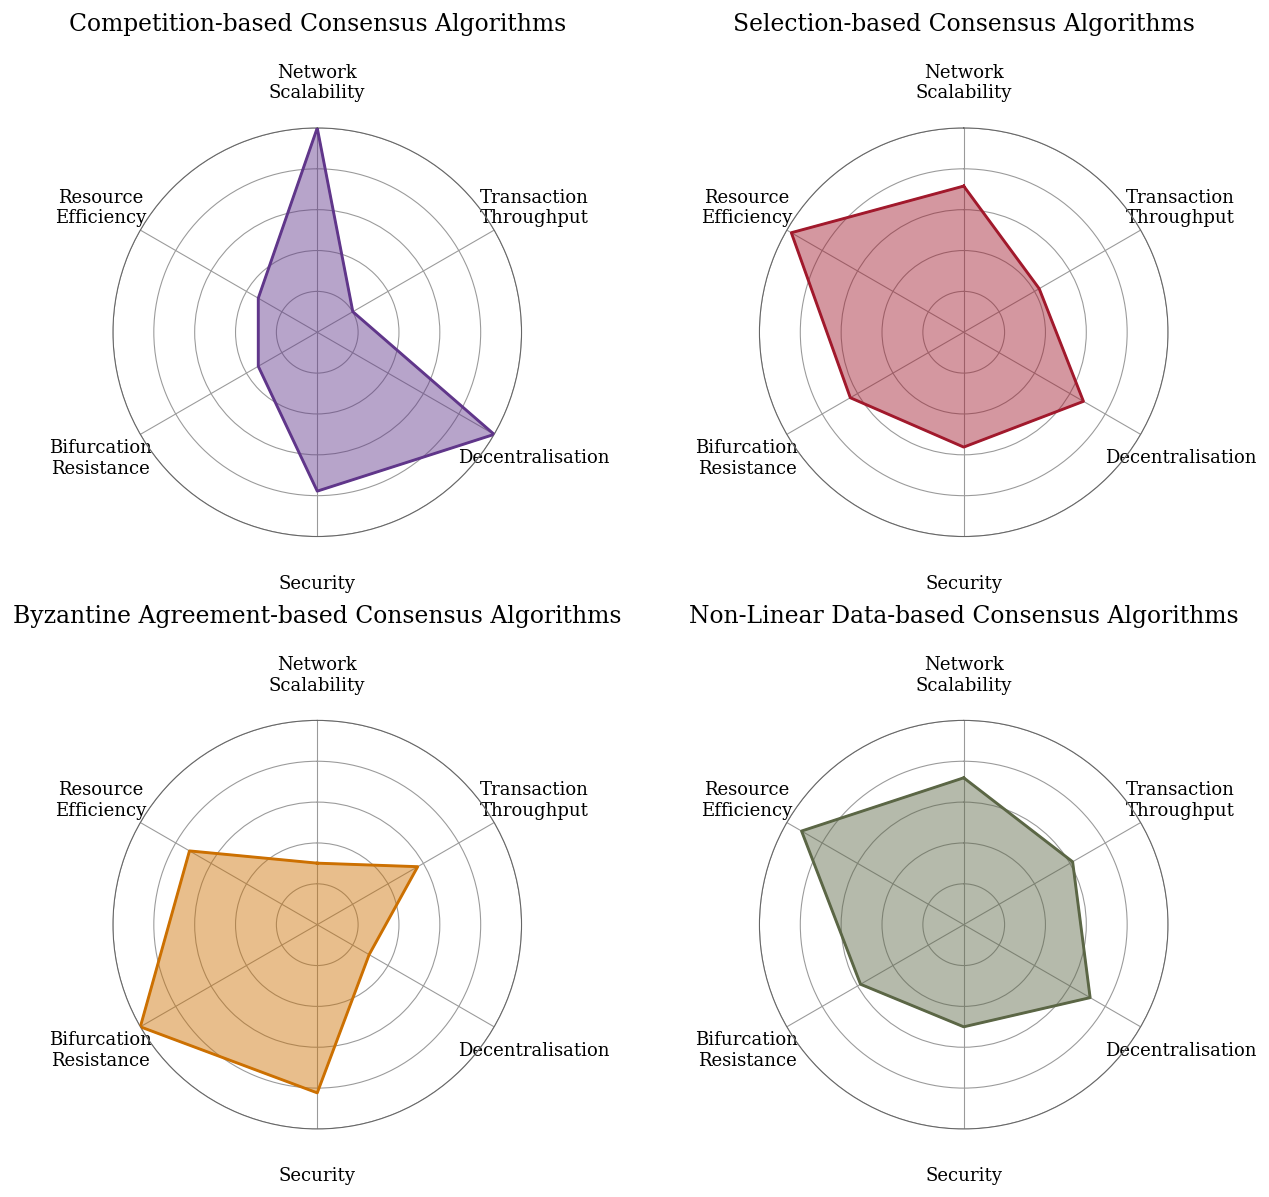

In [8]:
# AGGREGATION: MEAN
# Axis
AXIS_SPEC = [
    ("S_net", "Network\nScalability"),
    ("S_tps", "Transaction\nThroughput"),
    ("S_dec", "Decentralisation"),
    ("S_sec", "Security"),
    ("S_bif", "Bifurcation\nResistance"),
    ("S_res", "Resource\nEfficiency"),
]
plot_cols   = [c for c, _ in AXIS_SPEC]
axis_labels = [lab for _, lab in AXIS_SPEC]

#Radar chart order 
display_order = ["C", "S", "BA", "NL"]
family_titles = {
    "C":  "Competition-based Consensus Algorithms",
    "S":  "Selection-based Consensus Algorithms",
    "BA": "Byzantine Agreement-based Consensus Algorithms",
    "NL": "Non-Linear Data-based Consensus Algorithms",
}

# Choose aggregation
agg_table = family_mean


def draw_radar(ax, values, color, title):
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

    vals_closed   = values + values[:1]
    angles_closed = angles + angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.fill(angles_closed, vals_closed,
            color=color, alpha=CONFIG["fill_alpha"], zorder=2)
    ax.plot(angles_closed, vals_closed,
            color=color, linewidth=CONFIG["line_width"],
            alpha=CONFIG["line_alpha"], zorder=3)

    ax.set_xticks(angles)
    ax.set_xticklabels(axis_labels,
                       fontsize=CONFIG["axis_label_fontsize"],
                       color=CONFIG["axis_label_color"])
    ax.tick_params(axis='x', pad=15)

    levels = np.linspace(0, S_MAX, CONFIG["n_grid_levels"] + 1)[1:]
    ax.set_yticks(levels)
    ax.set_yticklabels([]) 
    ax.set_ylim(0, S_MAX)

    ax.grid(color=CONFIG["grid_color"],
            linewidth=CONFIG["grid_width"],
            linestyle=CONFIG["grid_linestyle"],
            zorder=1)
    ax.spines["polar"].set_color(CONFIG["spine_color"])
    ax.spines["polar"].set_linewidth(CONFIG["grid_width"])

    ax.set_title(title,
                 fontsize=CONFIG["title_fontsize"],
                 fontweight=CONFIG["title_fontweight"],
                 color=CONFIG["title_color"],
                 pad=18)

    if CONFIG["show_value_labels"]:
        for ang, val in zip(angles, values):
            ax.text(ang, val + CONFIG["value_label_offset"], f"{val:.1f}",
                    ha="center", va="center",
                    fontsize=CONFIG["value_label_fontsize"],
                    color=color, fontweight="bold")
            
fig, axs = plt.subplots(2, 2,
                        figsize=CONFIG["fig_size"],
                        dpi=CONFIG["fig_dpi"],
                        subplot_kw=dict(polar=True),
                        facecolor=CONFIG["background"])

if CONFIG["suptitle"]:
    fig.suptitle(CONFIG["suptitle"], fontsize=15, y=0.995)

for ax, fam in zip(axs.flat, display_order):
    values = agg_table.loc[fam, plot_cols].tolist()
    draw_radar(ax, values,
               color=CONFIG["family_colors"][fam],
               title=family_titles[fam])

plt.subplots_adjust(wspace=CONFIG["subplot_wspace"],
                    hspace=CONFIG["subplot_hspace"])
plt.show()
